# Titanic Survival Prediction

On April 15, 1912, the Titanic sank after hitting an iceberg. Of the 2,224 passengers and crew, 1,502 died. Survival wasn't random — factors like passenger class, age, sex, and where you were on the ship all played a role.

Your goal: train a model that looks at a passenger's details and predicts whether they survived.

This is a **binary classification** problem — the answer is either 0 (died) or 1 (survived).

This project is different from MNIST in an important way: the input is a **table of numbers**, not an image. So we'll use sklearn (like notebook 01) rather than PyTorch. No CNN needed — a decision tree or logistic regression is the right tool here.

## What you'll learn
- How to explore and clean real-world messy data
- How to turn non-numeric data (like "male"/"female") into numbers a model can use
- How to train and compare multiple models
- How to read a confusion matrix

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

print('Libraries loaded!')

Libraries loaded!


## Step 1: Load the Data

The Titanic dataset is built into seaborn — no download needed. It has one row per passenger and columns describing their details.

Always look at your data first before doing anything else. You want to understand:
- What columns exist and what they mean
- How many rows you have
- Whether any values are missing

In [13]:
df = sns.load_dataset('titanic')

print(f'Shape: {df.shape}')  # rows, columns
df.head(100)

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
97,1,1,male,23.0,0,1,63.3583,C,First,man,True,D,Cherbourg,yes,False
98,1,2,female,34.0,0,1,23.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [14]:
# Check for missing values — real data is almost always incomplete
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Column types:')
print(df.dtypes)

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Column types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


## Step 2: Explore the Data

Before training anything, look at the data visually. You want to get a feel for which features might actually matter for survival.

This step is called **EDA — Exploratory Data Analysis**. It helps you make better decisions about which columns to use and how to clean the data.

In [15]:
# Overall survival rate
print(f'Survived: {df["survived"].sum()} ({df["survived"].mean():.1%})')
print(f'Died:     {(df["survived"] == 0).sum()} ({1 - df["survived"].mean():.1%})')

Survived: 342 (38.4%)
Died:     549 (61.6%)


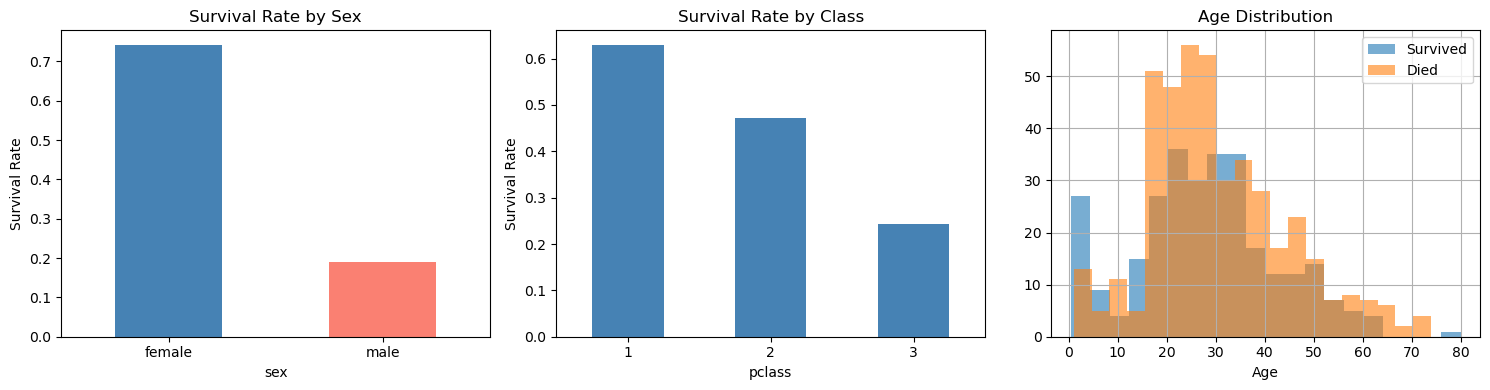

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by sex
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=0)

# Survival by passenger class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=0)

# Age distribution by survival
df[df['survived'] == 1]['age'].dropna().hist(ax=axes[2], alpha=0.6, label='Survived', bins=20)
df[df['survived'] == 0]['age'].dropna().hist(ax=axes[2], alpha=0.6, label='Died', bins=20)
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

You should see that sex and class are strong predictors — women and first class passengers survived at much higher rates. This matches the historical record ("women and children first").

## Step 3: Clean and Prepare the Data

Models can only work with numbers. Right now we have:
- Text columns like `sex` ("male"/"female") — need to convert to numbers
- Missing values in `age` — need to fill them in
- Columns that aren't useful for prediction — need to drop them

This step is called **feature engineering** — deciding which columns to use and how to prepare them.

In [17]:
# Work on a copy so we don't mess up the original
data = df.copy()

# Fill missing ages with the median age — better than dropping those rows
data['age'] = data['age'].fillna(data['age'].median())

# Convert sex to a number: male=0, female=1
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

# Convert embarkation port to numbers (where they boarded)
data['embarked'] = data['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
data['embarked'] = data['embarked'].fillna(0)  # fill the 2 missing values

# Select only the columns we'll use as features
# We drop: name, ticket, cabin (too unique/messy to be useful)
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = data[features]
y = data[target]

print(f'Features shape: {X.shape}')
print(f'Features used: {features}')
X.head()

Features shape: (891, 7)
Features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,0,22.0,1,0,7.2500,0.0
1,1,1,38.0,1,0,71.2833,1.0
2,3,1,26.0,0,0,7.9250,0.0
3,1,1,35.0,1,0,53.1000,0.0
4,3,0,35.0,0,0,8.0500,0.0


## Step 4: Split into Train and Test Sets

Same concept as MNIST — hold back some data the model never sees during training so you can honestly measure how well it generalizes.

80% train, 20% test is a common split for a dataset this size (891 passengers).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

Training samples: 712
Test samples:     179


## Step 5: Train Two Models and Compare

One of the advantages of sklearn is how easy it is to try different models. We'll train two and compare them:

**Logistic Regression** — despite the name, it's a classification model. It draws a straight dividing line between the two classes (survived/died) and puts each passenger on one side. Simple, fast, and easy to interpret.

**Random Forest** — builds hundreds of decision trees, each trained on a random subset of the data, then takes a vote. More powerful than a single tree and harder to overfit.

In [33]:
# Scale features — logistic regression works better when all features 
# are on the same scale (age 0-80 vs fare 0-500 is unfair otherwise)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

# Random Forest
rf = RandomForestClassifier(n_estimators=11000, random_state=42)
rf.fit(X_train, y_train)  # random forest doesn't need scaling
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f'Logistic Regression accuracy: {lr_acc:.1%}')
print(f'Random Forest accuracy:       {rf_acc:.1%}')

Logistic Regression accuracy: 79.9%
Random Forest accuracy:       81.6%


## Step 6: Understand the Results — Confusion Matrix

Accuracy alone doesn't tell the full story. A **confusion matrix** breaks down predictions into four buckets:

- **True Positive** — predicted survived, actually survived ✓
- **True Negative** — predicted died, actually died ✓
- **False Positive** — predicted survived, actually died ✗
- **False Negative** — predicted died, actually survived ✗

For some problems false negatives are much worse than false positives (e.g. missing a cancer diagnosis). Looking at the full matrix tells you *what kind* of mistakes the model makes.

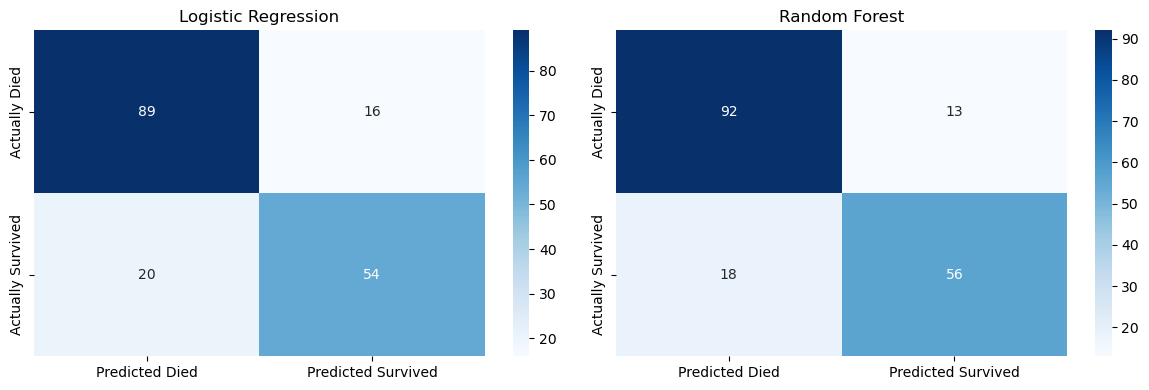

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Died', 'Predicted Survived'],
                yticklabels=['Actually Died', 'Actually Survived'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Step 7: Feature Importance

Random Forest can tell you which features it relied on most to make decisions. This is one of the most useful things you can do with a model — understand *why* it makes the predictions it does.

You'd expect `sex` and `pclass` to rank highly based on what you saw in the charts earlier.

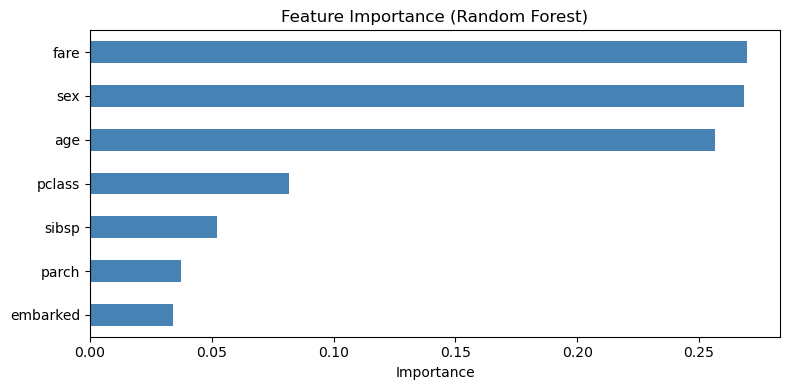

In [22]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Step 8: Predict a Specific Passenger

Let's make the model feel real — predict survival for a made-up passenger.

In [27]:
# Define a passenger
# pclass, sex (0=male 1=female), age, sibsp (siblings/spouses), parch (parents/children), fare, embarked
passenger = pd.DataFrame([{
    'pclass': 1,      # third class
    'sex': 0,         # male
    'age': 25,
    'sibsp': 0,       # no siblings or spouse
    'parch': 0,       # no parents or children
    'fare': 80.0,
    'embarked': 0     # Southampton
}])

prediction = rf.predict(passenger)[0]
probability = rf.predict_proba(passenger)[0]

print(f'Prediction: {"Survived" if prediction == 1 else "Did not survive"}')
print(f'Probability of survival: {probability[1]:.1%}')
print(f'Probability of death:    {probability[0]:.1%}')
print()
print('Try changing pclass to 1 or sex to 1 (female) and see how the probability changes!')

Prediction: Did not survive
Probability of survival: 39.7%
Probability of death:    60.3%

Try changing pclass to 1 or sex to 1 (female) and see how the probability changes!


## What You Built

A complete ML pipeline from raw data to predictions:
1. **Loaded** a real dataset with missing values and mixed data types
2. **Explored** it visually to understand which features matter
3. **Cleaned** it — filled missing values, converted text to numbers
4. **Trained** two different models and compared them
5. **Evaluated** with accuracy and a confusion matrix
6. **Interpreted** which features drove the predictions

This pipeline — load, explore, clean, train, evaluate — is the same one used on real ML projects, just at a larger scale.

## Things to Try

1. **Change the passenger** in Step 8 — make them female, or first class, and watch the probability change
2. **Add a new feature** — try creating an `is_child` column (`age < 12`) and add it to `features`
3. **Change `n_estimators`** in the Random Forest — try 10 vs 500 and see if accuracy changes
4. **Try a different model** — add `from sklearn.tree import DecisionTreeClassifier` and compare

## Bonus: Neural Network Approach

Can a PyTorch neural network do better than Random Forest on this data?

Probably not — 891 rows is very small for a neural network. But building one here lets you see exactly how the same data flows through a completely different kind of model.

The architecture is identical to the iris network from notebook 01 — a simple feedforward network with linear layers. No convolutions needed, because the input is a flat row of numbers, not an image.

Key differences from the sklearn models above:
- We have to convert the data to PyTorch tensors manually
- Training requires the familiar epoch loop with `zero_grad`, `backward`, `step`
- sklearn handles all of that for you in one `.fit()` call

Neural Network accuracy:      82.7%
Logistic Regression accuracy: 79.9%
Random Forest accuracy:       81.6%


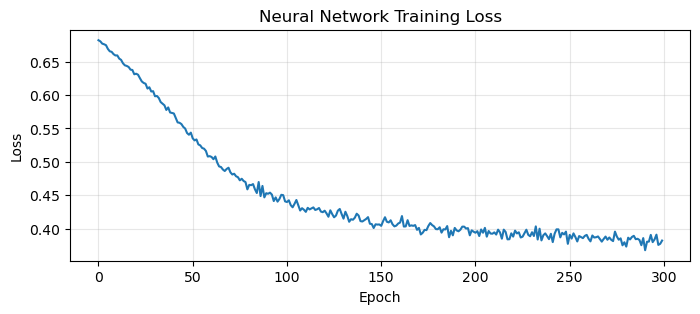


The neural network likely scores similarly to logistic regression.
With only 712 training rows, there is not enough data to give it an advantage.


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Convert the scaled numpy arrays to PyTorch tensors
# We use the scaled version since neural networks also benefit from scaled inputs
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long).to(device)

# Build the network
# Input: 7 features → hidden layer of 32 → hidden layer of 16 → 2 outputs (died/survived)
model = nn.Sequential(
    nn.Linear(7, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16, 2)   # 2 outputs: class 0 (died) and class 1 (survived)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop — same pattern as notebook 01 and MNIST
n_epochs = 300
losses = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Evaluate
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    nn_acc = (predicted == y_test_t).float().mean().item()

print(f'Neural Network accuracy:      {nn_acc:.1%}')
print(f'Logistic Regression accuracy: {lr_acc:.1%}')
print(f'Random Forest accuracy:       {rf_acc:.1%}')

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print()
print('The neural network likely scores similarly to logistic regression.')
print('With only 712 training rows, there is not enough data to give it an advantage.')